In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [39]:
# creating blobs cluster
X, y = make_blobs(n_samples=500, centers=3, cluster_std=0.60,
                  random_state=42)

# 500 datapoints | 3 clusters

In [40]:
X

array([[-6.1900632 , -7.30201545],
       [ 3.02174685,  1.94059276],
       [ 5.9537606 ,  1.48819071],
       [-2.74446251,  8.13617716],
       [ 5.36060719,  1.72832446],
       [ 5.13808033,  1.45951939],
       [-5.34357647, -6.93774553],
       [ 4.80215293,  1.94302682],
       [ 3.99930658,  1.88774199],
       [-7.25451834, -6.86445496],
       [ 4.25193511,  1.32424088],
       [-1.81404028,  8.52187674],
       [-1.2293776 ,  7.84303345],
       [-2.16666332,  9.69562551],
       [ 4.81374375,  3.21841016],
       [ 5.27493353,  0.91792599],
       [-2.5524037 ,  9.61640587],
       [-7.5532604 , -6.65066375],
       [-6.8302568 , -6.24082137],
       [-3.17299861,  8.29656215],
       [ 3.80073829,  2.31095123],
       [-2.38387947,  7.83848405],
       [ 4.98581301,  2.15991978],
       [-5.94031277, -6.91955975],
       [-7.14748736, -6.7636556 ],
       [ 4.87655012,  1.720579  ],
       [ 4.48689251,  2.87556548],
       [-6.4081471 , -6.62483506],
       [-6.71939703,

In [41]:
# converting X into dataframe
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [42]:
# standard scaling -> feature 2 has different values (not in fixed scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [43]:
# so, lets find out wcss value / inertia
inertia = []
k_range = range(1,11)

In [44]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [45]:
inertia

[1000.0000000000001,
 297.89541410517216,
 11.575484723104978,
 9.752067977356838,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595287,
 5.704177177901429,
 5.0602341335320755,
 4.762361898130396]

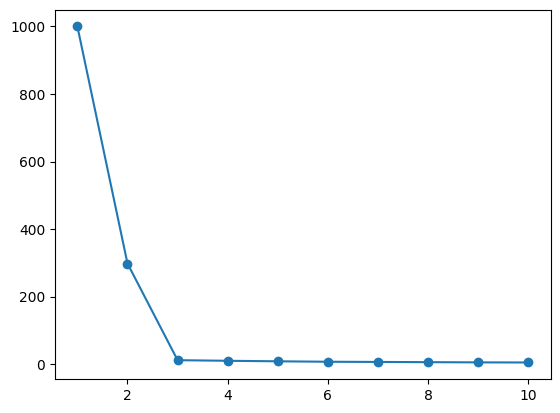

In [46]:
# lets visualize
plt.plot(k_range, inertia, marker='o')

In [47]:
# creating final kmeans cluster
kmeans_final = KMeans(n_clusters=6, random_state=42)

In [48]:
# making cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)
cluster_labels

array([5, 3, 0, 4, 0, 0, 5, 0, 3, 1, 3, 2, 2, 2, 0, 0, 4, 1, 1, 4, 3, 2,
       0, 5, 1, 0, 3, 5, 1, 2, 0, 2, 4, 4, 0, 3, 3, 3, 1, 5, 3, 2, 4, 2,
       2, 0, 3, 0, 3, 1, 1, 4, 1, 5, 0, 4, 2, 1, 0, 1, 1, 2, 3, 5, 3, 1,
       0, 5, 2, 0, 0, 0, 0, 5, 4, 1, 2, 3, 2, 4, 5, 2, 3, 2, 1, 1, 1, 1,
       3, 2, 5, 0, 4, 0, 0, 5, 2, 4, 2, 5, 3, 2, 2, 1, 5, 2, 4, 1, 4, 1,
       1, 1, 1, 5, 5, 3, 4, 1, 3, 1, 2, 2, 3, 3, 5, 0, 4, 3, 1, 5, 5, 0,
       3, 5, 0, 1, 5, 1, 3, 4, 5, 5, 0, 3, 5, 1, 1, 4, 2, 4, 3, 1, 3, 3,
       2, 1, 2, 5, 0, 3, 5, 1, 2, 2, 1, 4, 4, 0, 1, 1, 5, 2, 2, 1, 5, 4,
       4, 3, 0, 0, 2, 5, 2, 2, 5, 1, 2, 0, 2, 5, 1, 1, 5, 1, 4, 0, 2, 2,
       1, 0, 2, 2, 5, 1, 3, 5, 3, 4, 2, 1, 5, 0, 5, 4, 2, 1, 2, 5, 2, 0,
       3, 4, 1, 4, 3, 2, 4, 5, 3, 3, 3, 3, 4, 1, 5, 1, 2, 0, 2, 0, 3, 3,
       4, 4, 5, 1, 0, 4, 2, 3, 2, 2, 4, 2, 3, 4, 1, 4, 5, 4, 2, 2, 1, 4,
       3, 0, 0, 4, 0, 3, 2, 4, 0, 5, 4, 4, 4, 2, 1, 1, 2, 3, 2, 4, 1, 2,
       0, 5, 3, 0, 5, 4, 4, 2, 1, 4, 5, 3, 0, 2, 0,

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

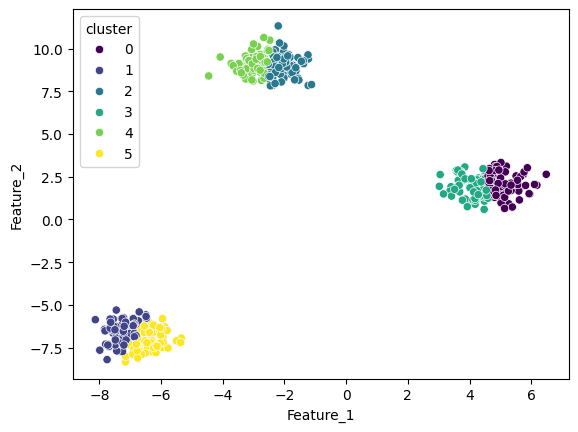

In [49]:
# to show graph, extraction of clusters are done
df['cluster'] = cluster_labels
sns.scatterplot(x=df['Feature_1'],
               y= df['Feature_2'],
               hue= df['cluster'],
               palette='viridis'
              )

## DbScan Clustering

In [50]:
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [52]:
from sklearn.cluster import KMeans, DBSCAN

# FOR this moons dataset, we will use KMeans and DbScan

In [53]:
# converting X into dataframe
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [54]:
# standard scaling -> feature 2 has different values (not in fixed scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [55]:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [57]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

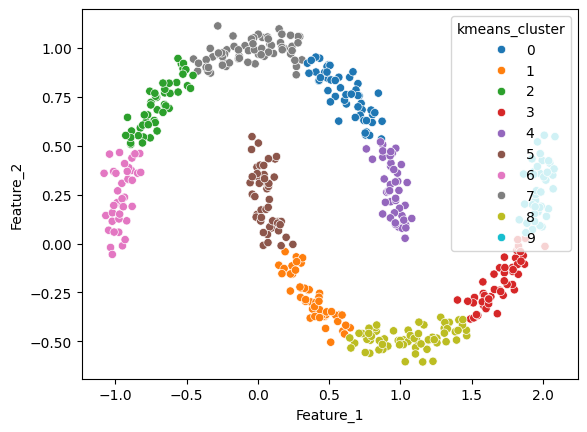

In [60]:
# plotting

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

### lets do DBSCAN

In [61]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [62]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

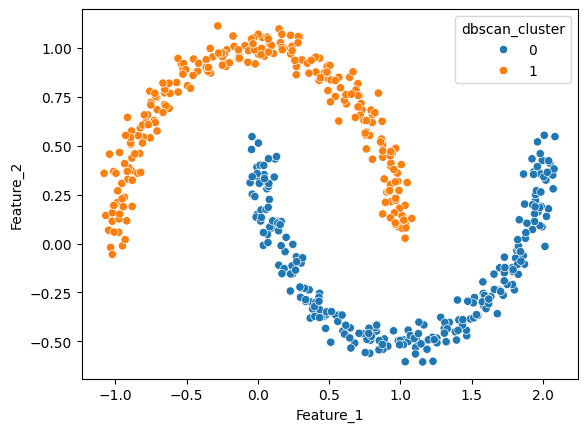

In [63]:
# plotting

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')

## PCA DIMENSIONALITY REDUCTION

In [64]:
from sklearn.decomposition import PCA

In [66]:
# creating blobs cluster
X, y = make_blobs(n_samples=500, centers=3, cluster_std=1.5, n_features =5,
                  random_state=42)

In [67]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

In [68]:
# standard scaling -> feature 2 has different values (not in fixed scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA

In [69]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [71]:
X_pca # 2 features instead of 5

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [74]:
# converting X into dataframe
df_pca = pd.DataFrame(X_pca, columns=['PC_1', 'PC_2'])
df_pca['label'] = y 

<Axes: xlabel='PC_1', ylabel='PC_2'>

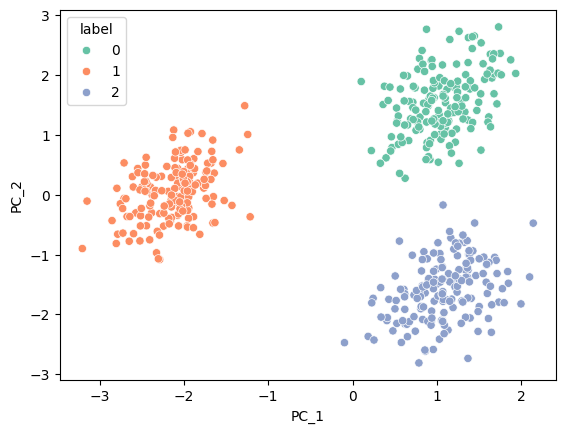

In [75]:
sns.scatterplot(data=df_pca, x='PC_1', y='PC_2', hue='label', palette="Set2")